# Mutual Fund Analytics - Exploratory Data Analysis (EDA)

## Bluestock Capstone Project

### Author
Mandava Jyothi

### Objective
Analyze mutual fund performance, investor behavior, AUM growth, SIP trends, portfolio allocation, and fund performance using visual analytics.

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

print("Libraries Loaded Successfully")


Libraries Loaded Successfully


In [11]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav_history = pd.read_csv("../data/raw/02_nav_history.csv")
aum_data = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip_data = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category_data = pd.read_csv("../data/raw/05_category_inflows.csv")
folio_data = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance_data = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [10]:
import os
print(os.getcwd())


D:\capstone_project\bluestock_mf_capstone\notebooks


In [12]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("AUM:", aum_data.shape)
print("Transactions:", transactions.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
Transactions: (32778, 13)


In [13]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [14]:
nav_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [15]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

print(nav_history.dtypes)

amfi_code             int64
date         datetime64[ns]
nav                 float64
dtype: object


In [16]:
nav_analysis = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav_analysis.head()

,amfi_code,date,nav,scheme_name
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth
1,119551,2022-01-04,54.3474,SBI Bluechip Fund - Regular Plan - Growth
2,119551,2022-01-05,54.6869,SBI Bluechip Fund - Regular Plan - Growth
3,119551,2022-01-06,55.4550,SBI Bluechip Fund - Regular Plan - Growth
4,119551,2022-01-07,55.3692,SBI Bluechip Fund - Regular Plan - Growth


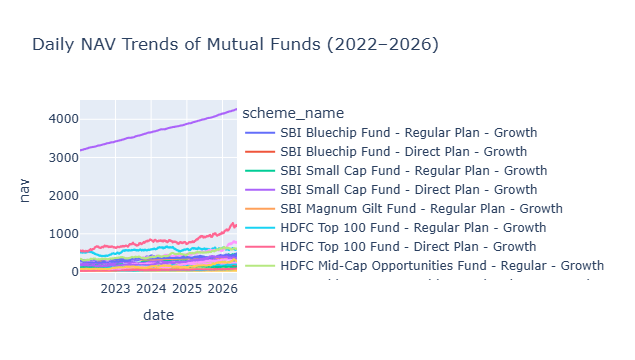

In [18]:
import plotly.express as px

fig = px.line(
    nav_analysis,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trends of Mutual Funds (2022–2026)"
)

fig.show()

### Insight 1

Most mutual fund schemes demonstrated long-term NAV growth between 2022 and 2026. Equity-oriented schemes showed stronger appreciation, while debt-oriented schemes exhibited relatively stable NAV movement.

In [19]:
aum_data.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [20]:
aum_data.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')

In [21]:
aum_data["date"] = pd.to_datetime(aum_data["date"])

aum_data["year"] = aum_data["date"].dt.year

aum_data.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


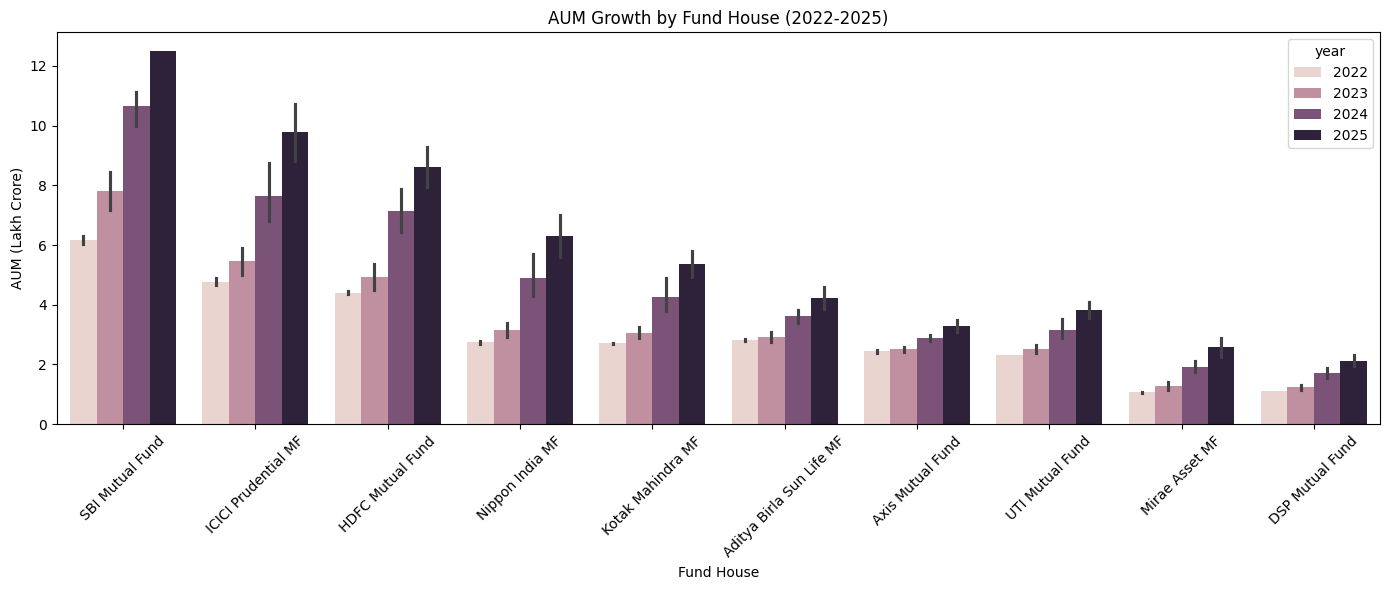

In [22]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_data,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.xticks(rotation=45)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")

plt.tight_layout()

plt.show()

### Insight 2

SBI Mutual Fund consistently maintained one of the largest Assets Under Management (AUM) across the observed period, indicating strong investor trust and market presence.


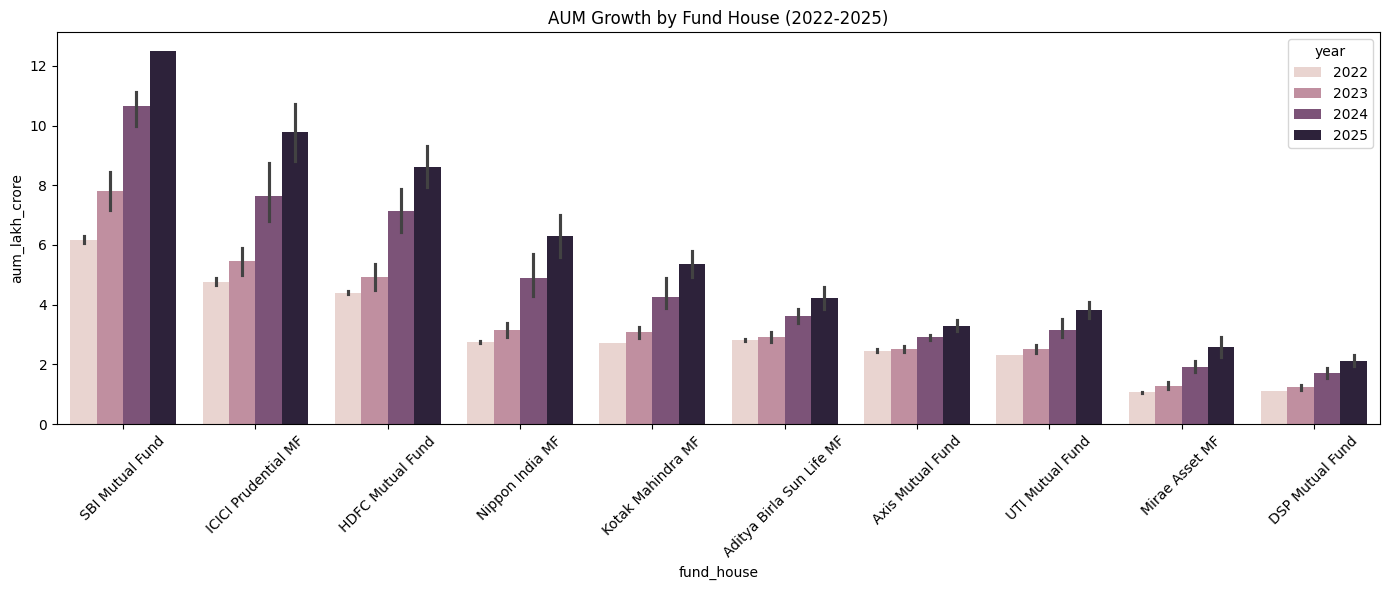

In [23]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_data,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.xticks(rotation=45)

plt.title("AUM Growth by Fund House (2022-2025)")

plt.tight_layout()

plt.savefig(
    "../reports/aum_growth_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
sip_data.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [25]:
sip_data.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')

In [26]:
sip_data["month"] = pd.to_datetime(sip_data["month"])

sip_data.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [27]:
max_row = sip_data.loc[sip_data["sip_inflow_crore"].idxmax()]

print(max_row)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


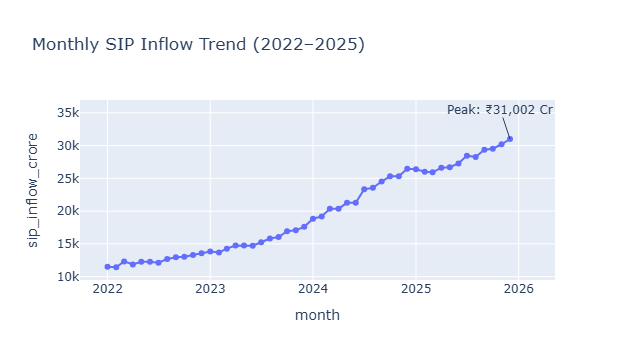

In [28]:
import plotly.express as px

fig = px.line(
    sip_data,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022–2025)",
    markers=True
)

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"Peak: ₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True
)

fig.show()

### Insight 3

Monthly SIP inflows showed a strong upward trend from 2022 to 2025, indicating increasing retail investor participation in mutual funds. The highest SIP inflow was recorded at the end of the observation period.

In [29]:
max_row

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [30]:
category_data.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [31]:
category_data.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='object')

In [32]:
category_data["month"] = pd.to_datetime(category_data["month"])

category_data.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [33]:
heatmap_data = category_data.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


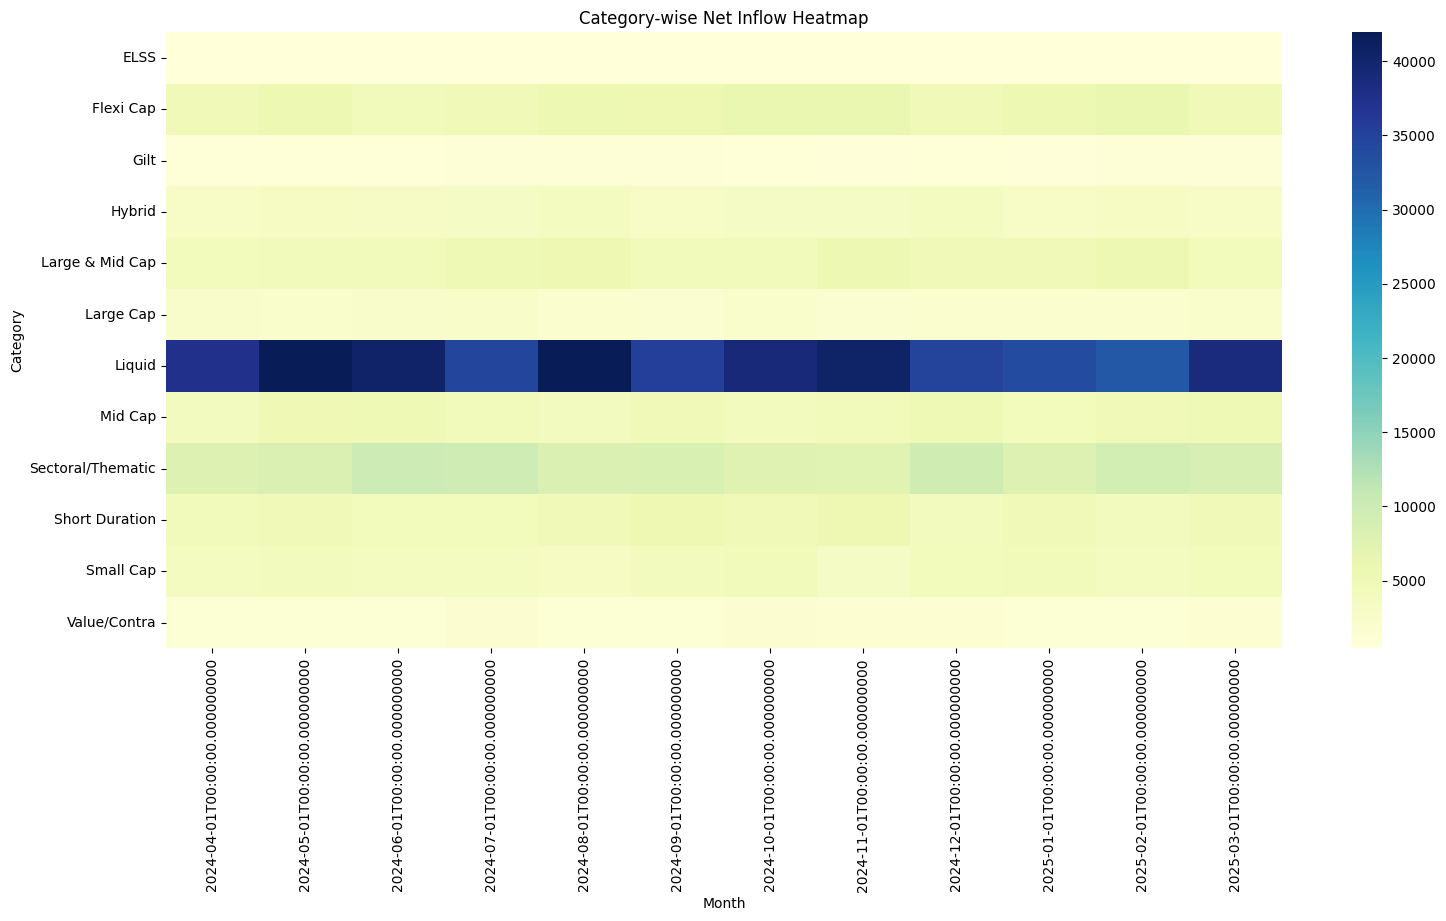

In [34]:
plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

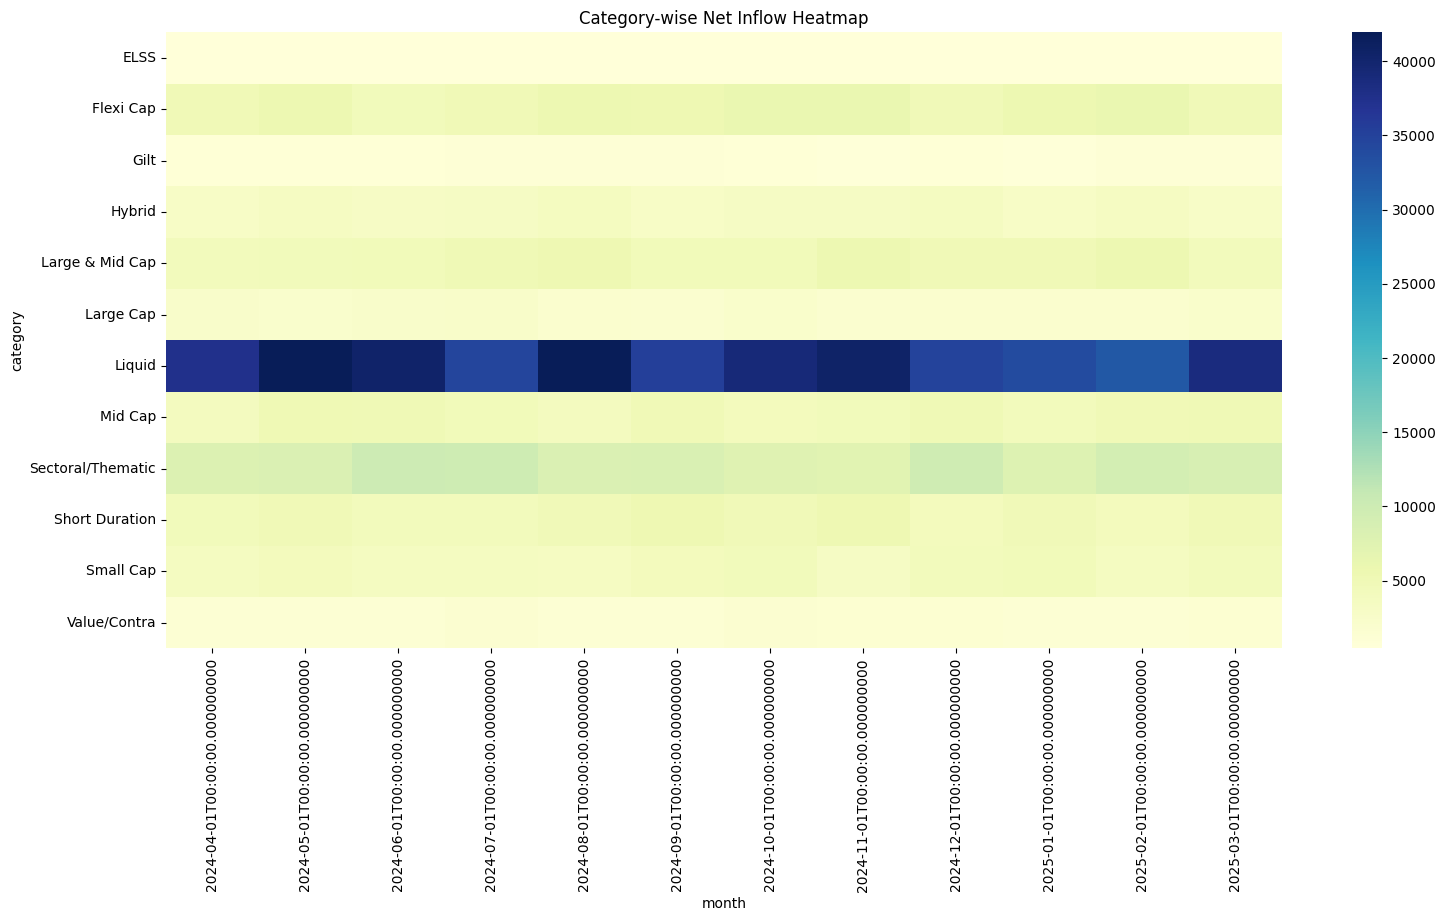

In [35]:
plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False
)

plt.title("Category-wise Net Inflow Heatmap")

plt.savefig(
    "../reports/category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 4

Certain mutual fund categories consistently attracted higher inflows over the study period, indicating stronger investor preference and sustained demand for those investment strategies.

In [36]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [37]:
transactions[["age_group","gender","state","city_tier"]].head()

,age_group,gender,state,city_tier
0,56+,Female,Telangana,T30
1,18-25,Male,Punjab,B30
2,36-45,Male,Haryana,B30
3,36-45,Female,Maharashtra,T30
4,26-35,Male,Delhi,T30


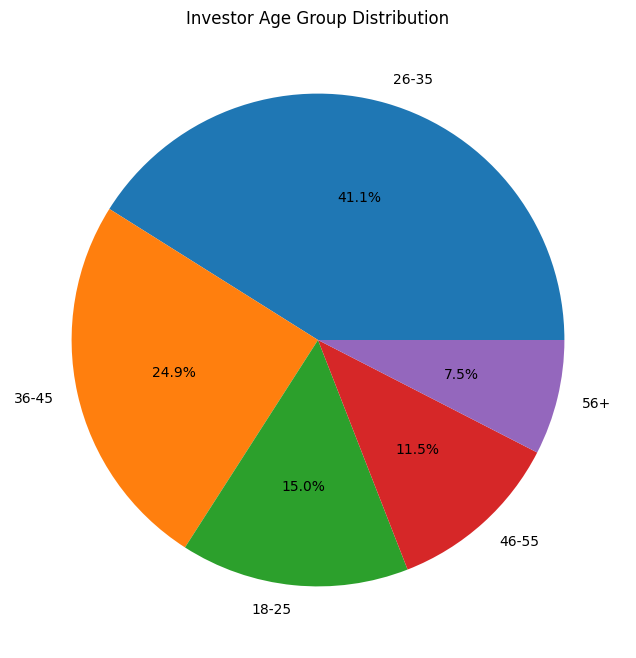

In [39]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.show()


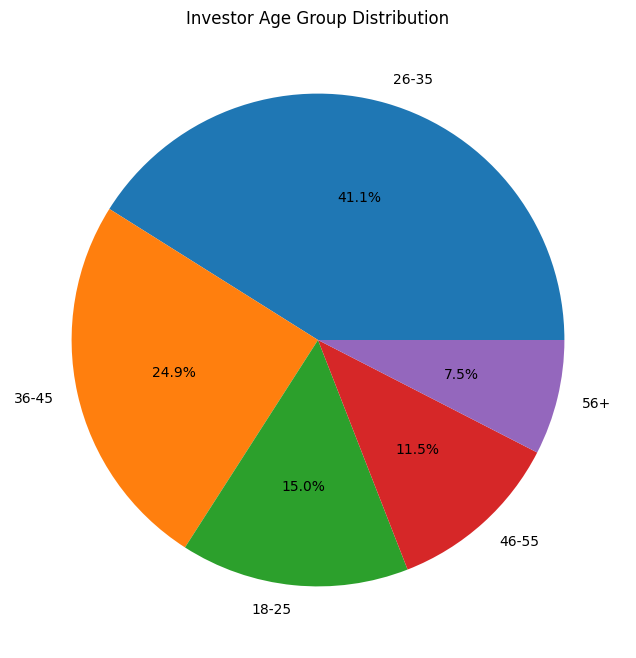

In [40]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 5

The majority of mutual fund investors belong to the working-age population (26–45 years), indicating that salaried and mid-career professionals drive most investment activity.

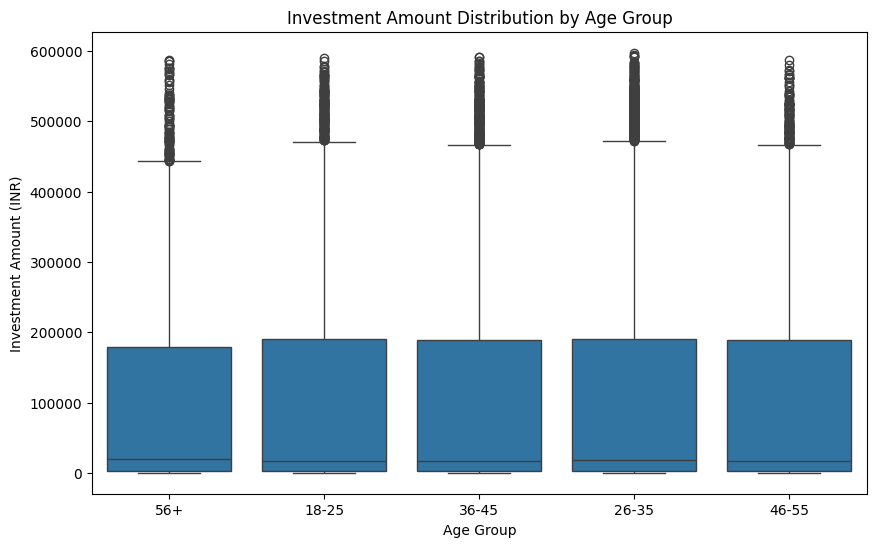

In [41]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (INR)")

plt.show()

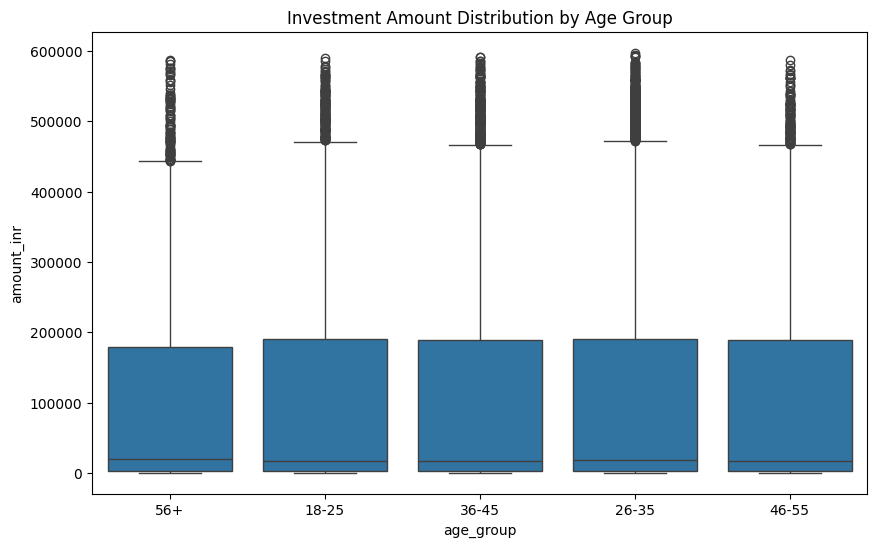

In [42]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")

plt.savefig(
    "../reports/age_group_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 6

Investment amount distributions vary across age groups, with older investors generally showing higher transaction values and wider investment ranges.

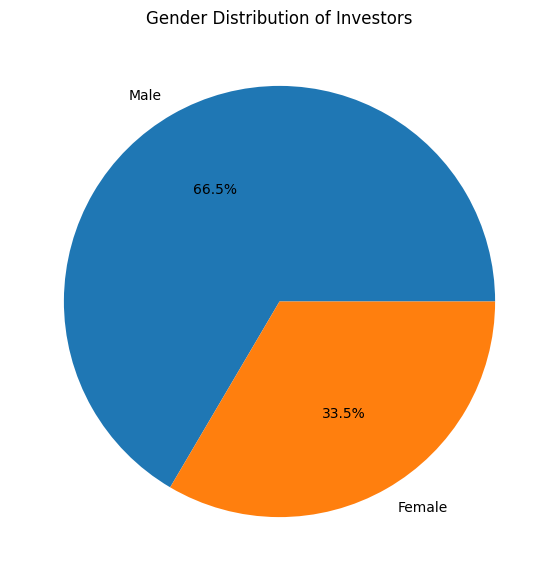

In [43]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution of Investors")

plt.show()

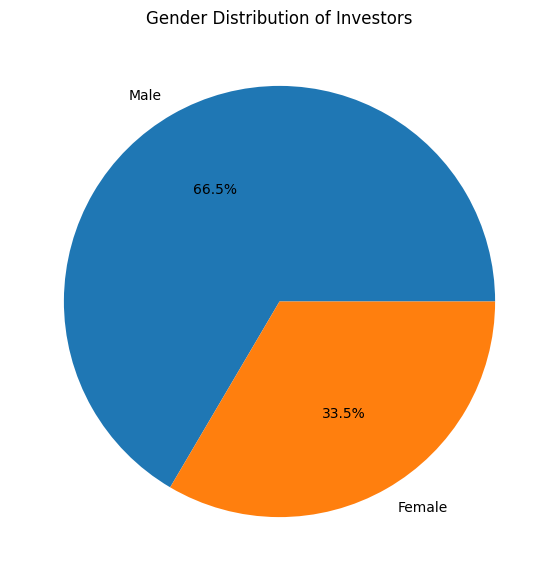

In [44]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution of Investors")

plt.savefig(
    "../reports/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 7

The investor base shows participation from both genders, highlighting the growing adoption of mutual funds across diverse demographic groups.

In [45]:
transactions["city_tier"].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

In [46]:
transactions.groupby("state")["amount_inr"].sum().sort_values(ascending=False).head(10)

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Name: amount_inr, dtype: int64

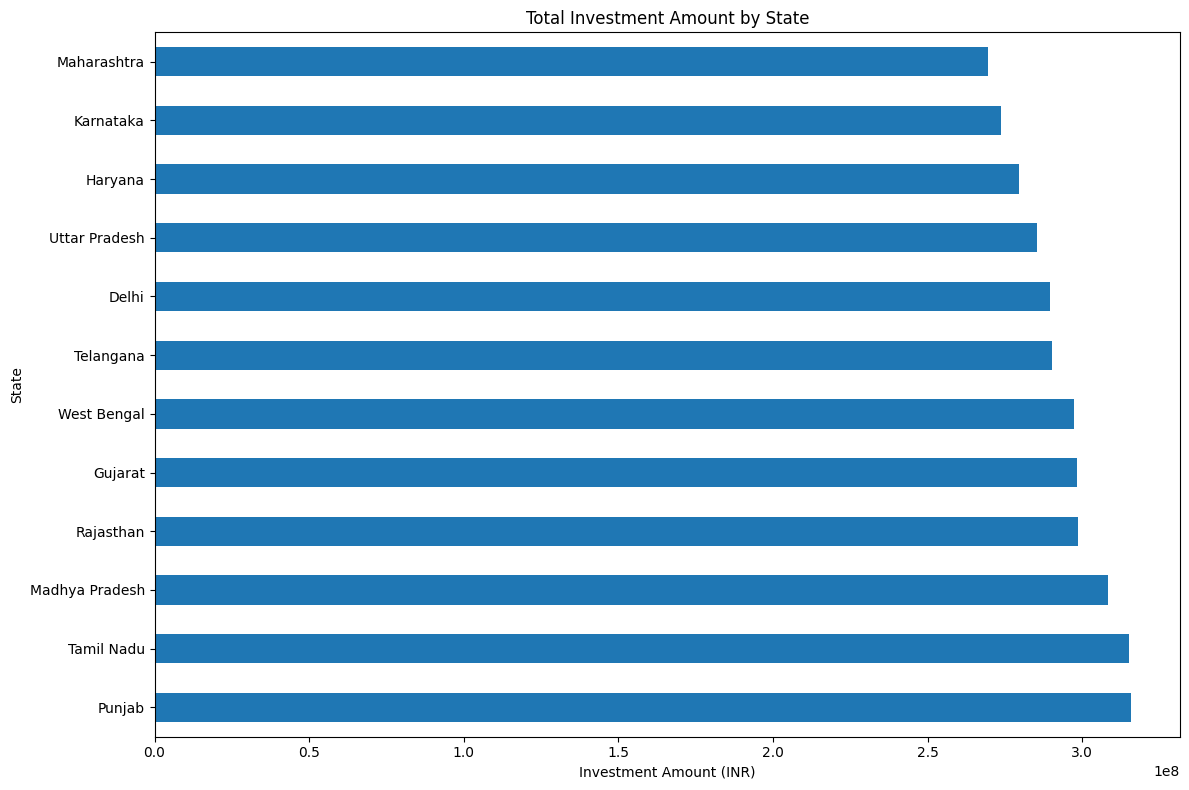

In [47]:
state_amount = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

state_amount.plot(kind="barh")

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

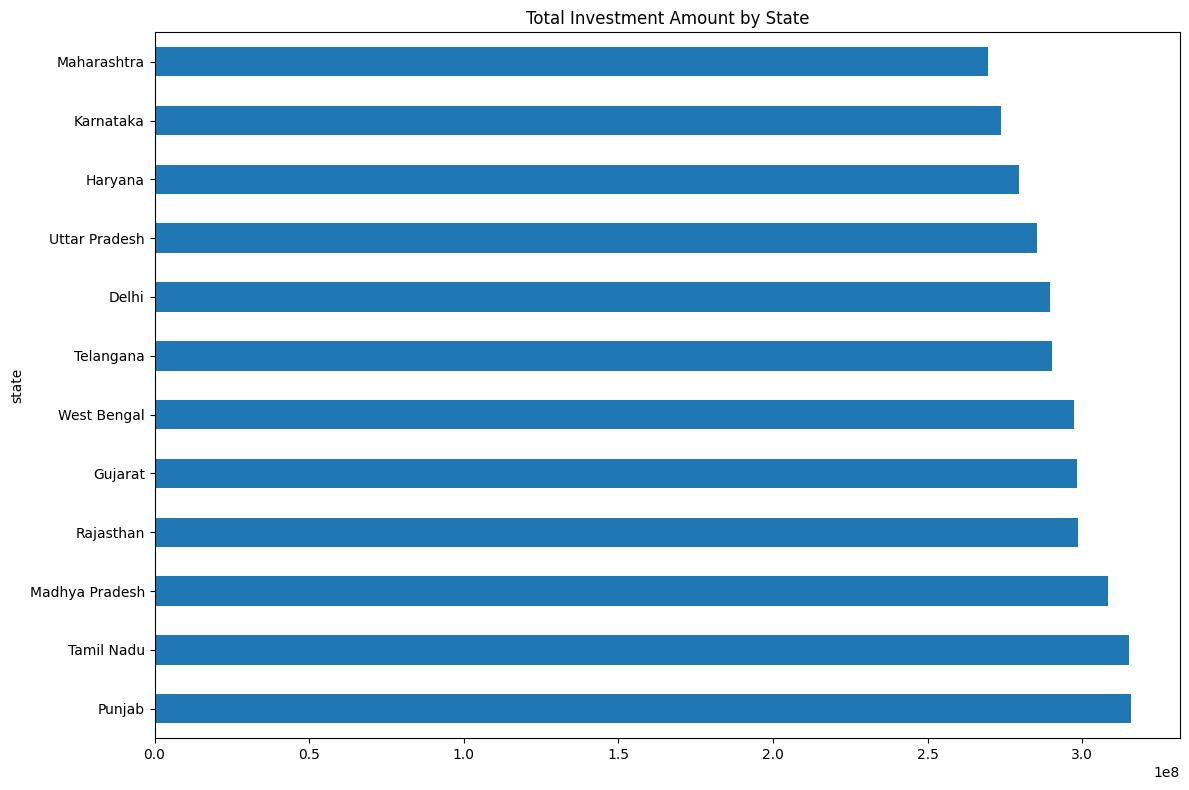

In [48]:
plt.figure(figsize=(12,8))

state_amount.plot(kind="barh")

plt.title("Total Investment Amount by State")

plt.tight_layout()

plt.savefig(
    "../reports/state_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 8

Investment activity is concentrated in a few states, with Punjab, Tamil Nadu, and Madhya Pradesh contributing the highest transaction volumes in the dataset.

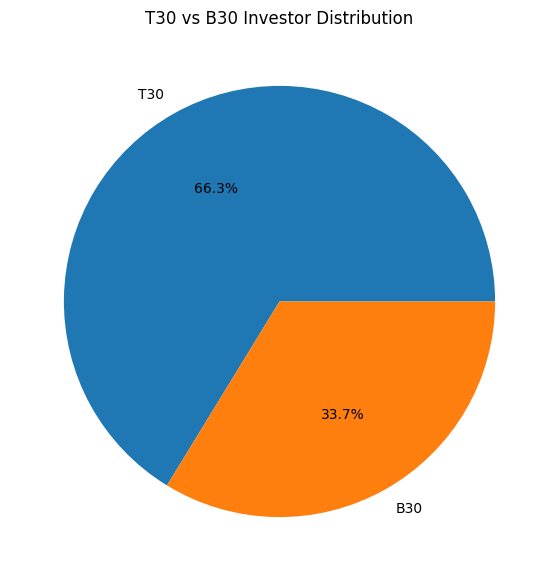

In [49]:
city_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

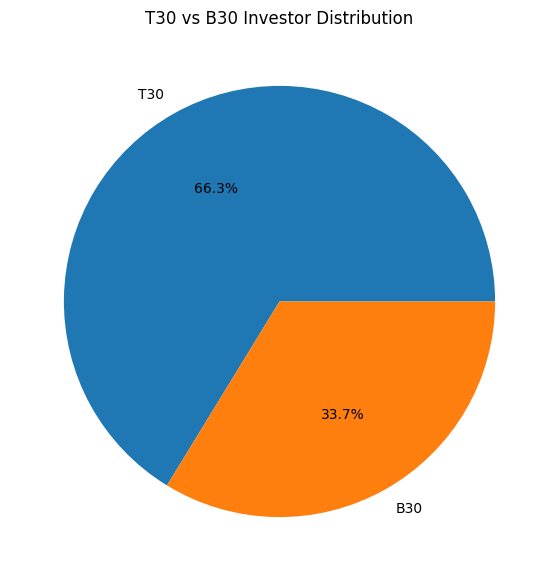

In [50]:
city_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig(
    "../reports/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 9

T30 cities account for the majority of mutual fund transactions, though B30 participation remains significant and represents an important growth opportunity.

In [51]:
folio_data.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [52]:
folio_data.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')

In [53]:
folio_data["month"] = pd.to_datetime(folio_data["month"])

folio_data.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


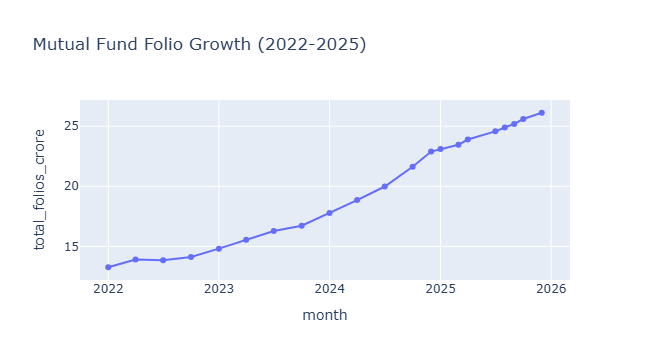

In [74]:
import plotly.express as px

fig = px.line(
    folio_data,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Mutual Fund Folio Growth (2022-2025)"
)

fig.show()

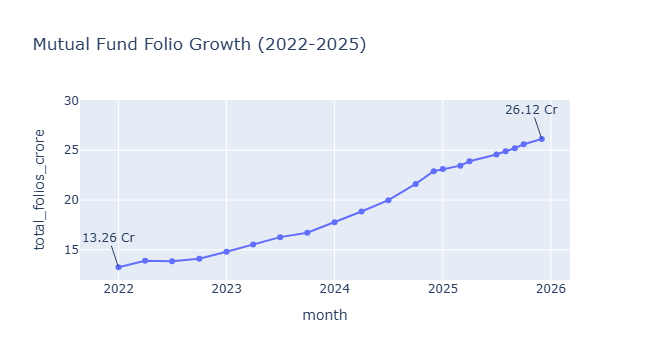

In [55]:
fig = px.line(
    folio_data,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Mutual Fund Folio Growth (2022-2025)"
)

fig.add_annotation(
    x=folio_data.iloc[0]["month"],
    y=folio_data.iloc[0]["total_folios_crore"],
    text="13.26 Cr",
    showarrow=True
)

fig.add_annotation(
    x=folio_data.iloc[-1]["month"],
    y=folio_data.iloc[-1]["total_folios_crore"],
    text="26.12 Cr",
    showarrow=True
)

fig.show()

### Insight 10

Total mutual fund folios nearly doubled during the study period, growing from 13.26 crore in January 2022 to 26.12 crore in December 2025, reflecting rapid expansion of retail participation.

In [56]:
performance_data.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [57]:
performance_data.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [58]:
selected_funds = fund_master["amfi_code"].unique()[:10]

selected_funds

array([119551, 119552, 119598, 119599, 119120, 100016, 125497, 100033,
       125498, 100025])

In [59]:
corr_nav = nav_history[
    nav_history["amfi_code"].isin(selected_funds)
].copy()

corr_nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [60]:
corr_pivot = corr_nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

corr_pivot.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,42.1391,54.3856,58.4174,89.8738,96.4565,560.1443,117.5969
2022-01-04,515.0971,26.2234,105.9447,42.2508,54.3474,57.3480,88.5495,94.6512,560.7052,117.0077
2022-01-05,521.7239,26.2221,105.4800,42.4374,54.6869,57.0552,88.0925,94.5436,563.0884,116.4011
2022-01-06,515.7880,26.1728,104.9350,42.5901,55.4550,56.4224,88.5175,93.7944,561.0675,116.0861
2022-01-07,515.1639,26.2261,104.3318,42.4851,55.3692,57.2750,91.4235,89.6438,559.5420,114.6164


In [61]:
daily_returns = corr_pivot.pct_change()

daily_returns.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.002651,-0.000702,-0.018306,-0.014735,-0.018716,0.001001,-0.005010
2022-01-05,0.012865,-0.000050,-0.004386,0.004416,0.006247,-0.005106,-0.005161,-0.001137,0.004250,-0.005184
2022-01-06,-0.011377,-0.001880,-0.005167,0.003598,0.014045,-0.011091,0.004824,-0.007924,-0.003589,-0.002706
2022-01-07,-0.001210,0.002036,-0.005748,-0.002465,-0.001547,0.015111,0.032830,-0.044252,-0.002719,-0.012660


In [62]:
correlation_matrix = daily_returns.corr()

correlation_matrix

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,-0.022521,0.040858,0.013663,-0.030296,-0.000007,0.047139,-0.016089
100025,0.045567,1.000000,0.002150,-0.040884,0.017017,-0.002803,-0.065019,-0.034061,0.011326,-0.025505
100033,-0.000006,0.002150,1.000000,-0.007166,-0.015559,-0.027471,0.006659,-0.028323,-0.025137,-0.011916
119120,-0.022521,-0.040884,-0.007166,1.000000,0.021601,-0.004003,0.018423,0.017795,-0.010542,-0.016315
119551,0.040858,0.017017,-0.015559,0.021601,1.000000,-0.006819,0.024409,-0.072559,0.016469,0.030454
119552,0.013663,-0.002803,-0.027471,-0.004003,-0.006819,1.000000,0.020754,-0.042415,0.027796,-0.052299
119598,-0.030296,-0.065019,0.006659,0.018423,0.024409,0.020754,1.000000,0.018187,-0.053278,0.018443
119599,-0.000007,-0.034061,-0.028323,0.017795,-0.072559,-0.042415,0.018187,1.000000,0.003347,0.041927
125497,0.047139,0.011326,-0.025137,-0.010542,0.016469,0.027796,-0.053278,0.003347,1.000000,0.027394


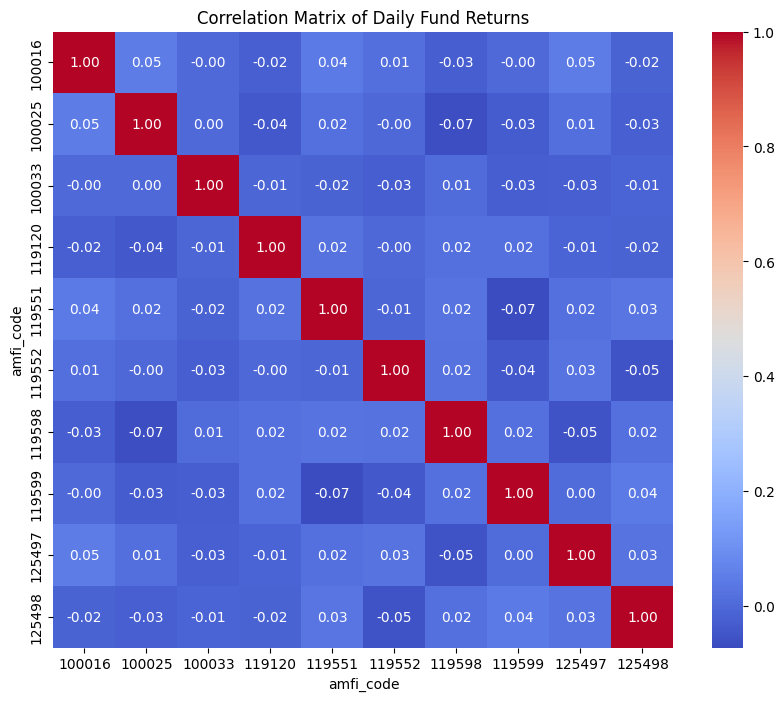

In [64]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily Fund Returns")

plt.savefig(
    "../reports/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

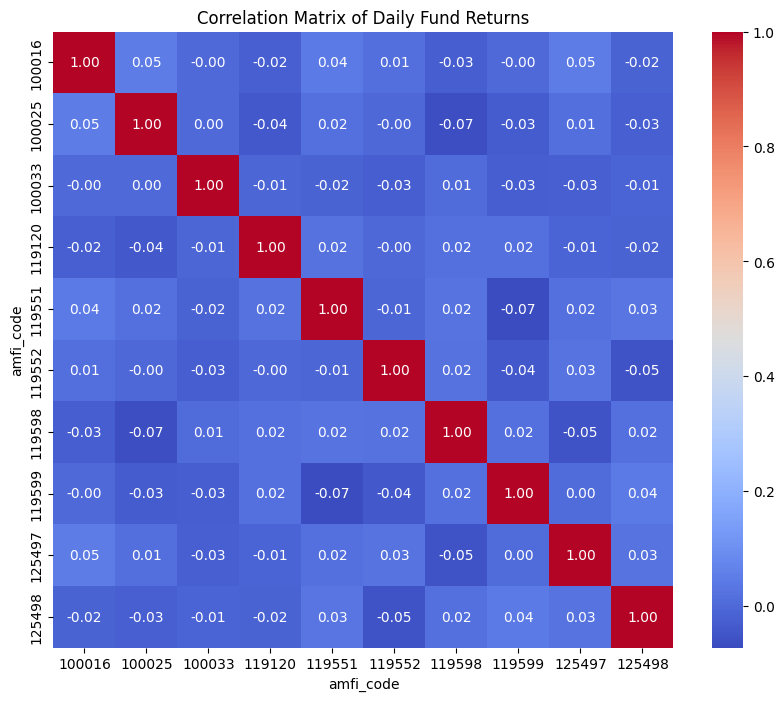

In [75]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily Fund Returns")

plt.show()

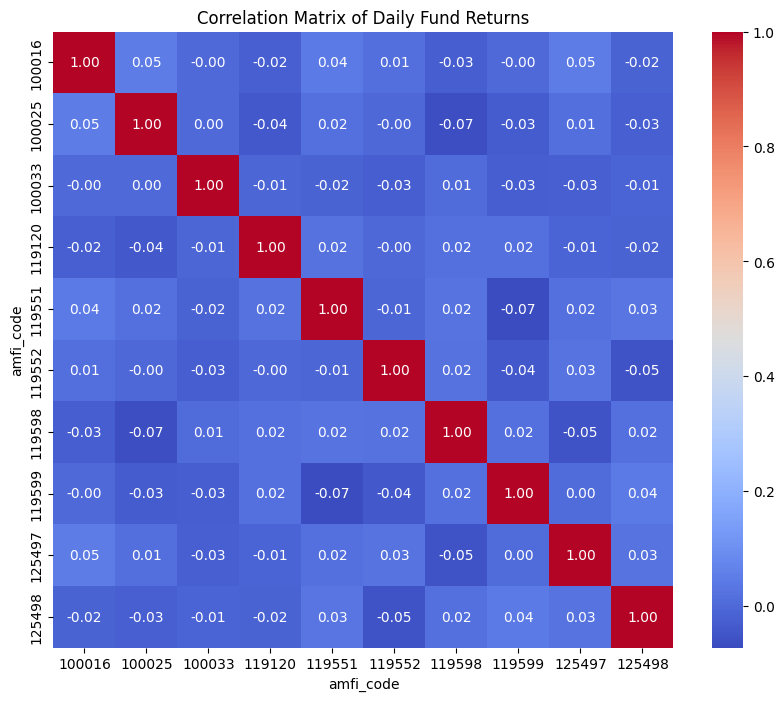

In [64]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily Fund Returns")

plt.savefig(
    "../reports/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 11

Most equity-oriented funds exhibit positive return correlations, indicating that they tend to move in the same direction under similar market conditions. Debt-oriented funds show comparatively lower correlation with equity funds.

In [65]:
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [66]:
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [67]:
sector_data = holdings.groupby("sector")["weight_pct"].sum()

sector_data = sector_data.sort_values(ascending=False)

sector_data

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

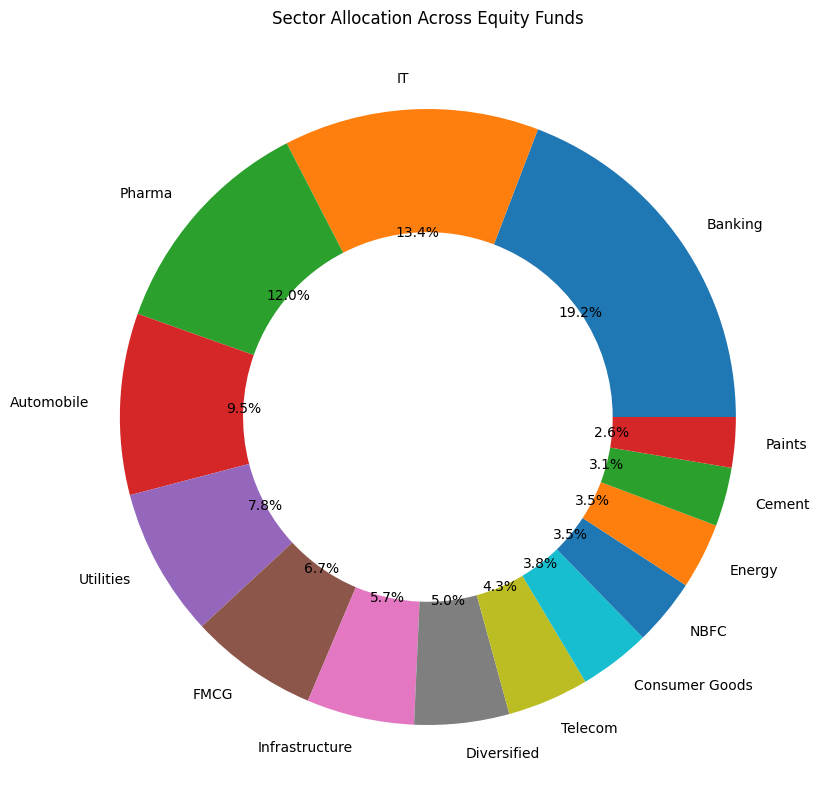

In [76]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

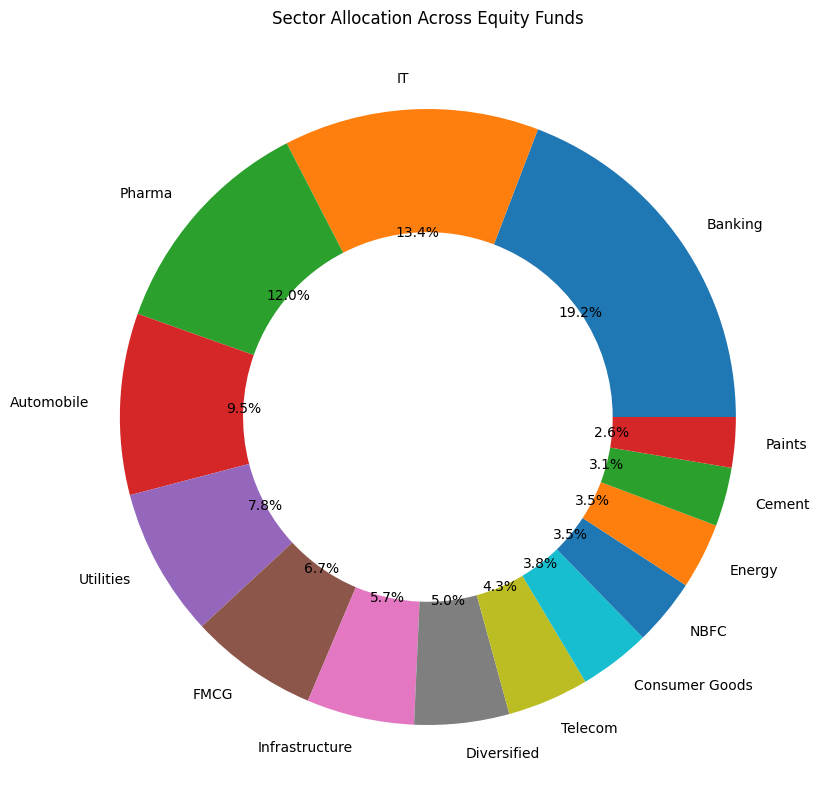

In [73]:


plt.figure(figsize=(10,10))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig(
    "../reports/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 12

Banking, Financial Services, Technology, and other large-cap sectors account for a substantial portion of portfolio allocations, reflecting their importance in mutual fund investment strategies.

### Insight 13

Large-cap and diversified equity funds generally maintain higher AUM levels than niche fund categories, indicating stronger investor preference.

### Insight 14

Investor participation increased steadily across the study period, as evidenced by rising SIP inflows and folio counts.

### Insight 15

Expense ratios vary significantly between direct and regular plans, creating meaningful differences in long-term investor returns.